# Comprehensive Analysis of Pickle Dataset

This notebook provides a detailed analysis of the serialized skeleton dataset (Pickle format). It covers:

- **Data Structure**: Root object type and sample fields.
- **Global Statistics**: Distribution of sequence lengths and coordinate ranges.
- **Data Integrity**: Assessment of missing landmarks (zero-value coordinates).
- **Spatial Segmentation**: Breakdown of the 86 keypoints into specific body regions (Hands, Mouth, Pose).
- **Visualization**: Graphical representation of the skeleton keypoints.

## 1. Setup and Data Loading

Initialize libraries and load the dataset from the specified path.

In [2]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Configuration
PICKLE_FILE_PATH = Path("../data/pickle/pose_bisindo.pkl")

print(f"Loading dataset from: {PICKLE_FILE_PATH}")
with open(PICKLE_FILE_PATH, "rb") as f:
    dataset = pickle.load(f)

print(f"Dataset loaded. Root type: {type(dataset)}")
print(f"Total number of samples: {len(dataset)}")

Loading dataset from: ..\data\pickle\pose_bisindo.pkl
Dataset loaded. Root type: <class 'dict'>
Total number of samples: 750


## 2. Basic Structure Exploration

Inspecting the internal structure of the samples and the format of the keypoint arrays.

In [3]:
if not isinstance(dataset, dict):
    raise TypeError(f"Expected root object to be a dictionary, but found {type(dataset)}")

video_ids = list(dataset.keys())
print(f"Total unique Video IDs: {len(video_ids)}")
print(f"First 5 Sample IDs: {video_ids[:5]}")

# Detailed inspection of the first sample
sample_id = video_ids[0]
sample_data = dataset[sample_id]

print(f"\n--- Sample Inspection: {sample_id} ---")
print(f"Sample Container Type: {type(sample_data)}")

if isinstance(sample_data, dict):
    print(f"Available fields: {list(sample_data.keys())}")

keypoints = sample_data.get("keypoints") if isinstance(sample_data, dict) else None

if isinstance(keypoints, np.ndarray):
    print(f"Keypoints Type: {type(keypoints)}")
    print(f"Keypoints Shape: {keypoints.shape} (Frames, Landmarks, Dims)")
    print(f"Data Type: {keypoints.dtype}")
    print(f"Coordinate Range: [{keypoints.min():.4f}, {keypoints.max():.4f}]")
else:
    print("Warning: 'keypoints' field not found or is not a NumPy array.")

Total unique Video IDs: 750
First 5 Sample IDs: ['P01_S001_R01', 'P01_S001_R02', 'P01_S001_R03', 'P01_S001_R04', 'P01_S001_R05']

--- Sample Inspection: P01_S001_R01 ---
Sample Container Type: <class 'dict'>
Available fields: ['keypoints']
Keypoints Type: <class 'numpy.ndarray'>
Keypoints Shape: (185, 86, 2) (Frames, Landmarks, Dims)
Data Type: float64
Coordinate Range: [0.0000, 1.1756]


## 3. Global Statistical Analysis

Analyzing distribution of sequence lengths and ensuring consistency across the entire dataset.

In [4]:
sequence_lengths = []
shape_registry = {}
dtype_registry = {}
invalid_samples = []

global_min = np.inf
global_max = -np.inf

for vid, data in dataset.items():
    keypoints = data.get("keypoints") if isinstance(data, dict) else None

    if not isinstance(keypoints, np.ndarray):
        invalid_samples.append((vid, type(keypoints)))
        continue

    sequence_lengths.append(keypoints.shape[0])

    # Register spatial dimensions (86, 2)
    spatial_shape = tuple(keypoints.shape[1:])
    shape_registry[spatial_shape] = shape_registry.get(spatial_shape, 0) + 1

    # Register data type
    dtype_str = str(keypoints.dtype)
    dtype_registry[dtype_str] = dtype_registry.get(dtype_str, 0) + 1

    # Track global coordinate range
    curr_min = np.min(keypoints)
    curr_max = np.max(keypoints)
    if curr_min < global_min: global_min = curr_min
    if curr_max > global_max: global_max = curr_max

sequence_lengths = np.array(sequence_lengths)

print(f"Total Samples Analyzed: {len(dataset)}")
print(f"Valid NumPy Samples: {len(sequence_lengths)}")
print(f"Invalid Samples Found: {len(invalid_samples)}")

print("\n--- Spatial Shape Distribution ---")
for shape, count in sorted(shape_registry.items(), key=lambda x: x[1], reverse=True):
    print(f"  {shape}: {count} samples")

print("\n--- Sequence Length Statistics (Frames) ---")
print(f"  Min Length    : {int(sequence_lengths.min())}")
print(f"  25th Percentile: {np.percentile(sequence_lengths, 25):.2f}")
print(f"  Median Length : {np.median(sequence_lengths):.2f}")
print(f"  Mean Length   : {sequence_lengths.mean():.2f}")
print(f"  75th Percentile: {np.percentile(sequence_lengths, 75):.2f}")
print(f"  Max Length    : {int(sequence_lengths.max())}")

print("\n--- Global Coordinate Range ---")
print(f"  Min Value: {global_min:.6f}")
print(f"  Max Value: {global_max:.6f}")

Total Samples Analyzed: 750
Valid NumPy Samples: 750
Invalid Samples Found: 0

--- Spatial Shape Distribution ---
  (86, 2): 750 samples

--- Sequence Length Statistics (Frames) ---
  Min Length    : 80
  25th Percentile: 145.00
  Median Length : 194.00
  Mean Length   : 204.38
  75th Percentile: 238.75
  Max Length    : 517

--- Global Coordinate Range ---
  Min Value: -0.074610
  Max Value: 1.786937


## 4. Data Integrity: Missing Landmarks

Coordinates at `[0.0, 0.0]` usually indicate that MediaPipe failed to detect those landmarks in a frame.

In [5]:
total_frames_count = 0
total_landmarks_count = 0
missing_landmarks_count = 0
frames_with_missing_data = 0

for data in dataset.values():
    keypoints = data.get("keypoints") if isinstance(data, dict) else None
    if not isinstance(keypoints, np.ndarray) or keypoints.ndim != 3:
        continue

    # Identify landmarks where both X and Y are zero
    # Shape: (Frames, 86, 2) -> missing_mask: (Frames, 86)
    missing_mask = np.all(keypoints == 0, axis=2)

    num_frames = keypoints.shape[0]
    num_landmarks = keypoints.shape[1]

    total_frames_count += num_frames
    total_landmarks_count += num_frames * num_landmarks
    
    missing_landmarks_count += int(missing_mask.sum())
    frames_with_missing_data += int(np.any(missing_mask, axis=1).sum())

print("--- Data Integrity Summary ---")
print(f"Total Frames in Dataset       : {total_frames_count}")
print(f"Frames with Missing Landmarks : {frames_with_missing_data}")
print(f"Percentage of Affected Frames : {(frames_with_missing_data / total_frames_count * 100):.2f}%")

print(f"\nTotal Keypoint Values Checked : {total_landmarks_count}")
print(f"Total Missing [0,0] Keypoints : {missing_landmarks_count}")
print(f"Overall Missing Data Rate    : {(missing_landmarks_count / total_landmarks_count * 100):.2f}%")

--- Data Integrity Summary ---
Total Frames in Dataset       : 153283
Frames with Missing Landmarks : 90908
Percentage of Affected Frames : 59.31%

Total Keypoint Values Checked : 13182338
Total Missing [0,0] Keypoints : 2417367
Overall Missing Data Rate    : 18.34%


## 5. Body Region Segmentation

Breaking down the 86 keypoints into their semantic regions based on the Holistic extractor layout.

In [6]:
# Select a sample for inspection
target_id = video_ids[2] if len(video_ids) > 2 else video_ids[0]
kp_array = dataset[target_id]["keypoints"]

print(f"Analyzing Segmentation for: {target_id}")
print(f"Array Shape: {kp_array.shape}")

# Slicing based on the 86-point layout:
# 0-20: Left Hand | 21-41: Right Hand | 42-60: Mouth | 61-85: Pose
left_hand  = kp_array[:, 0:21, :]
right_hand = kp_array[:, 21:42, :]
mouth      = kp_array[:, 42:61, :]
pose       = kp_array[:, 61:86, :]

print("\n--- Regional Shapes ---")
print(f"  Left Hand  : {left_hand.shape}")
print(f"  Right Hand : {right_hand.shape}")
print(f"  Mouth      : {mouth.shape}")
print(f"  Pose       : {pose.shape}")

print("\nFirst 5 points of Left Hand in Frame 0:")
np.set_printoptions(precision=4, suppress=True)
print(left_hand[0, :5, :])

Analyzing Segmentation for: P01_S001_R03
Array Shape: (173, 86, 2)

--- Regional Shapes ---
  Left Hand  : (173, 21, 2)
  Right Hand : (173, 21, 2)
  Mouth      : (173, 19, 2)
  Pose       : (173, 25, 2)

First 5 points of Left Hand in Frame 0:
[[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]


## 6. Visualization

Visualizing the skeleton for multiple speakers to verify spatial alignment. Note that Y-axis is inverted to match image coordinate systems (origin at top-left).

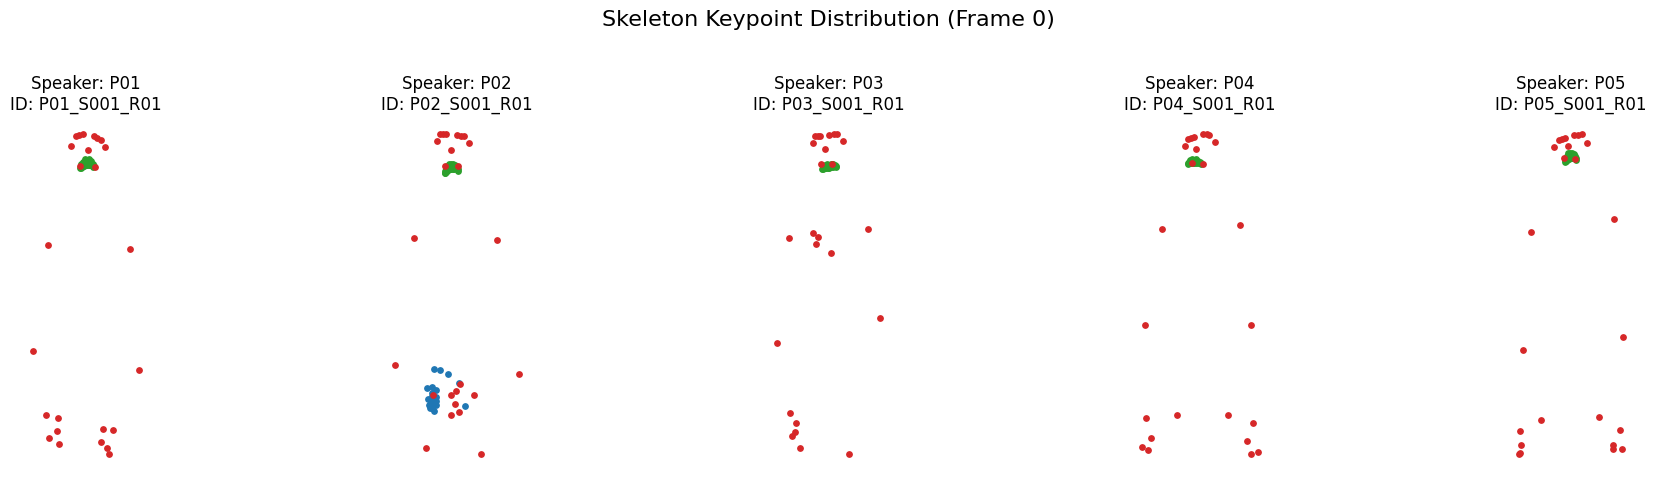

In [7]:
def filter_valid_points(points):
    """Removes [0,0] points from the plotting array."""
    mask = ~(np.logical_and(points[:, 0] == 0, points[:, 1] == 0))
    return points[mask]

speakers_to_plot = ["P01", "P02", "P03", "P04", "P05"]
selection = {}

for vid in dataset.keys():
    spk = vid.split('_')[0]
    if spk in speakers_to_plot and spk not in selection:
        selection[spk] = vid
    if len(selection) == len(speakers_to_plot): break

if selection:
    fig, axes = plt.subplots(1, len(selection), figsize=(20, 5))
    if len(selection) == 1: axes = [axes]

    for ax, (spk, vid) in zip(axes, sorted(selection.items())):
        kp = dataset[vid]["keypoints"][0]  # Take first frame
        
        # Region Segmentation for plotting
        pts_lh = filter_valid_points(kp[0:21])
        pts_rh = filter_valid_points(kp[21:42])
        pts_mo = filter_valid_points(kp[42:61])
        pts_po = filter_valid_points(kp[61:86])

        ax.scatter(pts_lh[:, 0], -pts_lh[:, 1], s=15, label="Left Hand")
        ax.scatter(pts_rh[:, 0], -pts_rh[:, 1], s=15, label="Right Hand")
        ax.scatter(pts_mo[:, 0], -pts_mo[:, 1], s=15, label="Mouth")
        ax.scatter(pts_po[:, 0], -pts_po[:, 1], s=15, label="Pose")

        ax.set_title(f"Speaker: {spk}\nID: {vid}")
        ax.set_aspect('equal')
        ax.axis('off')
    
    plt.suptitle("Skeleton Keypoint Distribution (Frame 0)", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print("No samples found for visualization.")